<a href="https://colab.research.google.com/github/25wh1a0520-web/Nasscom/blob/main/Copy_of_U6_probabilityweek2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Core imports for the whole lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

# We use the built-in 'tips' dataset (no file upload needed).
# In your own work this would be: pd.read_csv('data.csv')
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()
# 1. Numerical vs categorical columns
numerical_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

# 2. Mean of a numerical column (tip)
print("Mean of tip:", df['tip'].mean())

# 3. Value counts of a categorical column (sex)
print("Value counts of sex:")
print(df['sex'].value_counts())

Loaded tips dataset: (244, 7)
Numerical columns: ['total_bill', 'tip', 'size']
Categorical columns: []
Mean of tip: 2.99827868852459
Value counts of sex:
sex
Male      157
Female     87
Name: count, dtype: int64


Mean: 2.99827868852459
Median: 2.9
Mode: 2.0
Is tip right-skewed? True


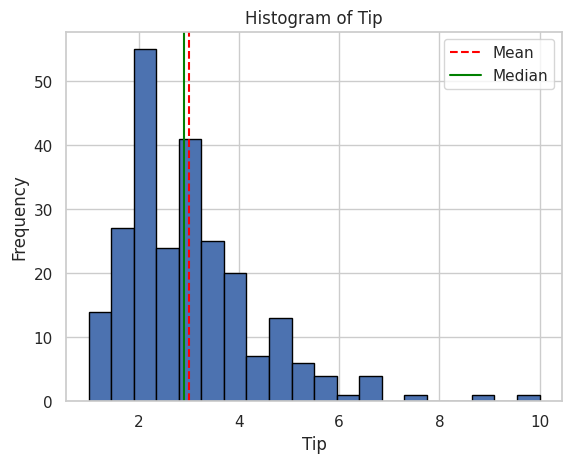

In [ ]:
tip = df['tip']

# 1. mean, median, mode
mean_tip = tip.mean()
median_tip = tip.median()
mode_tip = tip.mode()[0]

print("Mean:", mean_tip)
print("Median:", median_tip)
print("Mode:", mode_tip)

# 2. mean > median ?
print("Is tip right-skewed?", mean_tip > median_tip)

# 3. histogram with mean & median lines
import matplotlib.pyplot as plt

plt.hist(tip, bins=20, edgecolor='black')
plt.axvline(mean_tip, color='red', linestyle='--', label='Mean')
plt.axvline(median_tip, color='green', linestyle='-', label='Median')

plt.xlabel('Tip')
plt.ylabel('Frequency')
plt.title('Histogram of Tip')
plt.legend()
plt.show()

In [ ]:
tip = df['tip']

# 1. range, variance, std
tip_range = tip.max() - tip.min()
tip_variance = tip.var()
tip_std = tip.std()

print("Range:", tip_range)
print("Variance:", tip_variance)
print("Standard deviation:", tip_std)

# 2. Q1, Q3, IQR
Q1 = tip.quantile(0.25)
Q3 = tip.quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

# 3. Most robust measure of spread = IQR, because it is less affected by outliers.

Range: 9.0
Variance: 1.9144546380624725
Standard deviation: 1.3836381890011826
Q1: 2.0
Q3: 3.5625
IQR: 1.5625


Five-number summary:
min     1.0000
25%     2.0000
50%     2.9000
75%     3.5625
max    10.0000
Name: tip, dtype: float64
Skewness: 1.4654510370979401


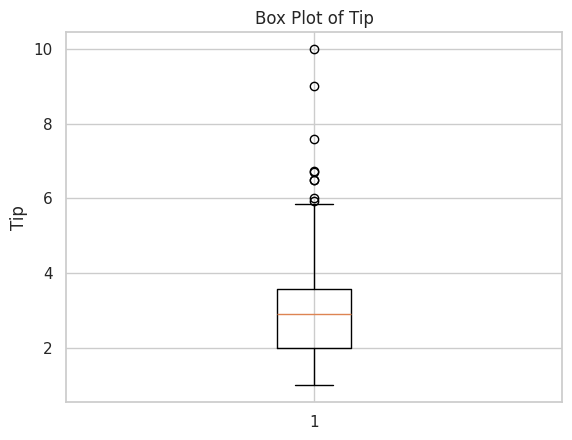

In [ ]:
tip = df['tip']

# 1. five-number summary
print("Five-number summary:")
print(tip.describe()[['min', '25%', '50%', '75%', 'max']])

# 2. skewness (+ comment on the direction of the lean)
skewness = tip.skew()
print("Skewness:", skewness)

# Positive skewness means the distribution leans to the right.
# For tip, it is right-skewed.

# 3. box plot of tip
import matplotlib.pyplot as plt

plt.boxplot(tip)
plt.ylabel('Tip')
plt.title('Box Plot of Tip')
plt.show()

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


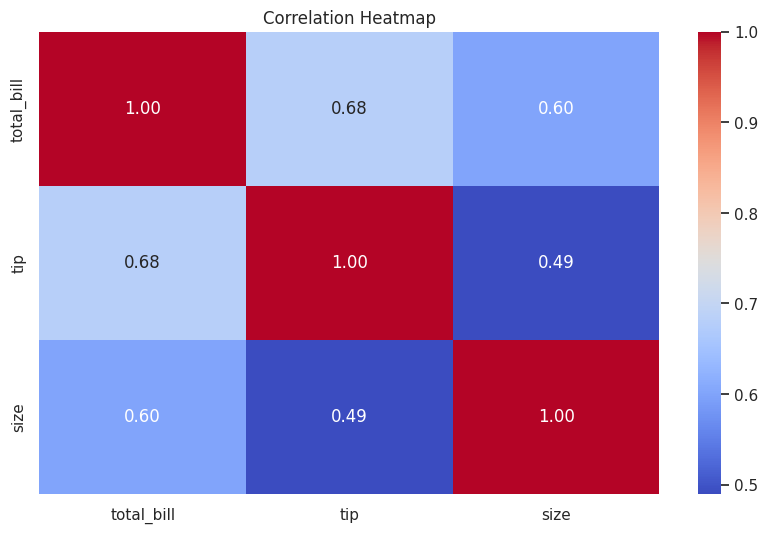

       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [ ]:
# 1. correlation matrix (rounded)
corr_matrix = df.corr(numeric_only=True).round(2)
print(corr_matrix)

# 2. heatmap of the correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# 3. df.describe() + 3 insights as comments
print(df.describe())

# Insight 1: Total_bill has the largest standard deviation, so it is the most spread-out variable.
# Insight 2: Total_bill and tip have a strong positive correlation.
# Insight 3: Tip is positively skewed, meaning the distribution has a longer tail on the right.